In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from utils.simulacoes import simular_PID, simular_step_test

from utils.plots import plot_results

In [2]:
SEED = 23

np.random.seed(SEED)

In [3]:
tf = 100.0
dt = 0.1

X0 = 0.3066
S0 = 0.2333

states = np.array([0.3066, 0.2333])

Xsp = 0.3066

D0 = 0.35


In [39]:
# funções auxiliares
def ajuste_string(individuo: list = None, tipo_param: str = "Kp"):
    if tipo_param == "Ti":
        individuo = ['+'] + individuo
        
    digitos_completar = 6 - len(individuo)
    while digitos_completar > 0:
        individuo.append('0')
        digitos_completar-=1
    return individuo

def gerar_mask_cruzamento():
    mask = np.array([
                    0,
                    np.random.randint(0, 2),
                    0,
                    np.random.randint(0, 2),
                    np.random.randint(0, 2),
                    np.random.randint(0, 2)
                ])
    
    return mask

def selecao(erro_individuo_lim, gen, tf, dt):
    erro_min = np.inf
    fortes = []
    fracos = []
    erros = []

    for individuo in gen:
        erro_individuo = np.inf
        # só pode ser selecionado se Ti != 0
        if individuo[1] != 0:
            t1, X1, S1, D1, IAE, ISE, erro = simular_PID(Kc=individuo[0], Ti=individuo[1], Xsp=Xsp, D0=D0, states=states, tempo_final=tf, dt=dt, show=False)
            erro_individuo = erro[-1] 

        if erro_individuo <= erro_individuo_lim: 
            fortes.append(individuo)
        else:
            fracos.append(individuo)
            
        erros.append(erro_individuo)
        
        # menor erro dentro dessa geracao
        if erro_min > erro_individuo:
            erro_min = erro_individuo
                
    return fortes, fracos, erros, erro_min

def cruzamento(fortes, pc: int = 1):
    filhos = np.zeros(shape=(len(fortes),2))
    
    for i in range(0, len(fortes), 2):
        # escolha dos pais
        idx_pai, idx_mae = np.random.choice(len(fortes),size=2,replace=False)
        
        # sorteia se esse par vai copular
        r = np.random.uniform(0, 1)
        if r <= pc:
            # crossover para o Kp
            pai = fortes[idx_pai, 0]
            mae = fortes[idx_mae, 0]
                
            arr_p = np.array(ajuste_string(list(str(pai)), tipo_param="Kp"))
            arr_m = np.array(ajuste_string(list(str(mae)), tipo_param="Kp"))

            mask_Kp = gerar_mask_cruzamento()
                
            # gera dois filhos Kp
            filhos[i, 0] = float(''.join(np.where(mask_Kp, arr_m, arr_p)))
            filhos[i + 1, 0] = float(''.join(np.where(mask_Kp, arr_p, arr_m)))

            # crossover para o Ti
            pai = fortes[idx_pai, 1]
            mae = fortes[idx_mae, 1]
                
            arr_p = np.array(ajuste_string(list(str(pai)), tipo_param="Ti"))
            arr_m = np.array(ajuste_string(list(str(mae)), tipo_param="Ti"))

            mask_Ti = gerar_mask_cruzamento()
            
            # gera dois filhos Ti  
            filhos[i, 1] = float(''.join(np.where(mask_Ti, arr_m, arr_p)))
            filhos[i + 1, 1] = float(''.join(np.where(mask_Ti, arr_p, arr_m)))
        else:
            # caso não possam acasalar, os pais são sujeitos direto a mutação
            filhos[i] = fortes[idx_mae]
            filhos[i + 1] = fortes[idx_pai]
        
    return filhos

def mutacao_gene(cromossomo, pm):
    for gene in range(len(cromossomo)):
            if (gene != 0 and gene != 2):
                r = np.random.uniform(0, 1)
                if r < pm:
                    cromossomo[gene] = str(np.random.randint(0, 10))
    
    return cromossomo
    
def mutacao(populacao, pm: float = 0.1):
    for i in range(len(populacao)):
        Kp = populacao[i, 0]
        Ti = populacao[i, 1]
        
        cromossomo_Kp = np.array(ajuste_string(list(str(Kp)), tipo_param="Kp"))
        cromossomo_Ti = np.array(ajuste_string(list(str(Ti)), tipo_param="Ti"))
        
        cromossomo_Kp = mutacao_gene(cromossomo_Kp, pm)
        cromossomo_Ti = mutacao_gene(cromossomo_Ti, pm)
        
        populacao[i, 0] = float(''.join(cromossomo_Kp))
        populacao[i, 1] = float(''.join(cromossomo_Ti))
        
    return populacao

In [38]:
#np.random.seed(SEED)
pai = 2.5
mae = 1.2

arr_p = np.array(ajuste_string(list(str(pai)), tipo_param="Ti"))
arr_m = np.array(ajuste_string(list(str(mae)), tipo_param="Ti"))

print(arr_p)
print(arr_m)

mask1 = gerar_mask_cruzamento()
mask2 = gerar_mask_cruzamento()
print(mask1)
print(mask2)

filho1 = float(''.join(np.where(mask1, arr_m, arr_p)))
filho2 = float(''.join(np.where(mask1, arr_p, arr_m)))
print(filho1)
print(filho2)

filhos = np.zeros(shape=(100,2))

cromossomo = mutacao_gene(arr_p, 0.1)
print(cromossomo)
a = [[1, 2], 
     [2, 3]]
b = np.zeros(shape=(98,2))
r = np.concatenate([mutacao(np.array(a)), b]) if len(a) > 0 else b
print(r)
print(len(r))

['+' '2' '.' '5' '0' '0']
['+' '1' '.' '2' '0' '0']
[0 1 0 0 0 1]
[0 0 0 0 0 0]
1.5
2.2
['+' '2' '.' '5' '5' '0']
[[100900.  20000.]
 [200000.  30000.]
 [     0.      0.]
 [     0.      0.]
 [     0.      0.]
 [     0.      0.]
 [     0.      0.]
 [     0.      0.]
 [     0.      0.]
 [     0.      0.]
 [     0.      0.]
 [     0.      0.]
 [     0.      0.]
 [     0.      0.]
 [     0.      0.]
 [     0.      0.]
 [     0.      0.]
 [     0.      0.]
 [     0.      0.]
 [     0.      0.]
 [     0.      0.]
 [     0.      0.]
 [     0.      0.]
 [     0.      0.]
 [     0.      0.]
 [     0.      0.]
 [     0.      0.]
 [     0.      0.]
 [     0.      0.]
 [     0.      0.]
 [     0.      0.]
 [     0.      0.]
 [     0.      0.]
 [     0.      0.]
 [     0.      0.]
 [     0.      0.]
 [     0.      0.]
 [     0.      0.]
 [     0.      0.]
 [     0.      0.]
 [     0.      0.]
 [     0.      0.]
 [     0.      0.]
 [     0.      0.]
 [     0.      0.]
 [     0.      0.]
 [     0.   

In [6]:

def sobrevivenciaMaisApto(tamanho_povo, N, erro_individuo_lim, gen, tf, dt):
    df = None
    historico_erro = []
    while N > 0:
        custo_erro = np.inf
        sobreviventes = []
        erro_sobreviventes = []

        for i in gen:
            # só se presta como gente
            if i[1] != 0:
                t1, X1, S1, D1, IAE, ISE, erro = simular_PID(Kc=i[0], Ti=i[1], Xsp=Xsp, D0=D0, states=states, tempo_final=tf, dt=dt, show=False)
                erro_individuo = erro[-1] 

                if erro_individuo <= erro_individuo_lim: 
                    sobreviventes.append(i)
                    erro_sobreviventes.append(erro_individuo)

                # menor erro dentro dessa geracao
                if custo_erro > erro_individuo:
                    custo_erro = erro_individuo
            
        historico_erro.append(custo_erro)
        df = pd.DataFrame({
                "sobreviventes": sobreviventes,
                "erro": erro_sobreviventes
            })
        
        # o menor custo de quem não morreu foi top, para aqui
        if abs(custo_erro) < 1e-5:
            break
        
        sobreviventes = np.array(sobreviventes)
        gen = np.zeros(shape=(tamanho_povo,2))
        for i in range(len(gen)):
            filho = np.zeros(2)

            # sodomia i
            idx_pai, idx_mae = np.random.choice(len(sobreviventes),size=2,replace=False)
            # print(f"idx_pai:{idx_pai}, idx_mae:{idx_mae}")

            # só no kzinho
            pai = sobreviventes[idx_pai, 0]
            mae = sobreviventes[idx_mae, 0]
            
            arr_p = np.array(ajuste_string(list(str(pai)), tipo_param="Kp"))
            arr_m = np.array(ajuste_string(list(str(mae)), tipo_param="Kp"))

            mask_Kp = gerar_mask_cruzamento()
            
            filho[0] = float(''.join(np.where(mask_Kp, arr_m, arr_p)))

            # só no T
            pai = sobreviventes[idx_pai, 1]
            mae = sobreviventes[idx_mae, 1]
            
            arr_p = np.array(ajuste_string(list(str(pai)), tipo_param="Ti"))
            arr_m = np.array(ajuste_string(list(str(mae)), tipo_param="Ti"))

            mask_Ti = gerar_mask_cruzamento()
            
            filho[1] = float(''.join(np.where(mask_Ti, arr_m, arr_p)))

            # filho i
            # print(filho)
            gen[i] = filho

        N-=1
    return df, N, historico_erro
        

In [40]:
def sobrevivenciaMaisApto_teste(iter_max, erro_individuo_lim, gen, tf, dt):
    df = None
    historico_erro = []
    while iter_max > 0:
        # seleção da geração
        fortes, fracos, erros, erro_min = selecao(erro_individuo_lim= erro_individuo_lim, gen= gen, tf=tf, dt=dt)
             
        # salva erro minimo de cada geração
        historico_erro.append(erro_min)
        
        df = {
                "fortes": fortes,
                "fracos": fracos,
                "erro": erros
            }
        
        # o menor custo da geração foi top, para aqui
        if abs(erro_min) < 1e-5:
            break
        
        filhos = []
        if len(fortes) >= 2:
            filhos = cruzamento(np.array(fortes))
            filhos = mutacao(filhos) 

        # nova geracao
        # gen = mutacao(np.array(fracos)) + filhos
        gen = np.concatenate([mutacao(np.array(fracos)), filhos]) if len(fracos) > 0 else filhos

        iter_max-=1
    return df, iter_max, historico_erro
        

In [41]:
tamanho_povo = 100
N = 10
erro_individuo_lim = 1e-2

# g init
gen = np.column_stack([
    -np.round(np.random.uniform(0, 5, tamanho_povo), 3),  # sempre negativo
    np.round(np.random.uniform(0, 10, tamanho_povo), 3),
])

for tuning_parameter_indice in range(len(gen)):
    # Checa casos em que Ti = 0
    while gen[tuning_parameter_indice, 1] == 0:
       gen[tuning_parameter_indice, 1] = np.round(np.random.uniform(0, 10), 3)

# povo, N, historico_erro = sobrevivenciaMaisApto(tamanho_povo=tamanho_povo, N=N, erro_individuo_lim=erro_individuo_lim, gen=gen, dt=0.1, tf = 50)
povo, N, historico_erro = sobrevivenciaMaisApto_teste(iter_max=N, erro_individuo_lim=erro_individuo_lim, gen=gen, dt=0.1, tf = 50)

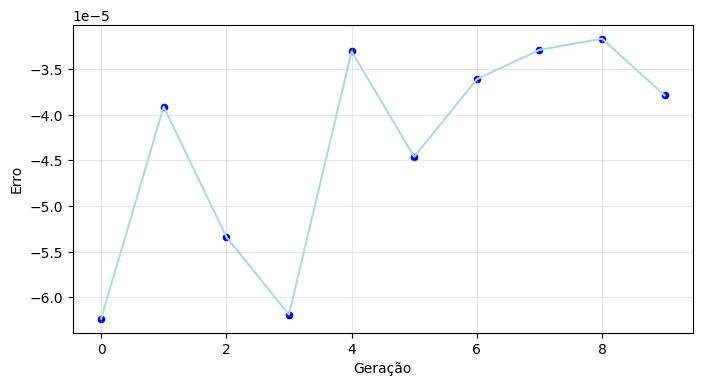

In [42]:
import matplotlib.pyplot as plt
import numpy as np

tempo = np.arange(len(historico_erro))

plt.figure(figsize=(8,4))

plt.plot(
    tempo,
    historico_erro,
    color='lightblue',
    linewidth=1.5
)

plt.scatter(
    tempo,
    historico_erro,
    color='blue',
    s=20
)

plt.xlabel("Geração")
plt.ylabel("Erro")
plt.grid(True, alpha=0.3)

plt.show()

In [ ]:
# Ordena pelo erro (usando valor absoluto)
indices_ordenados = np.argsort(np.abs(povo["erro"]))

povo_ordenado = {
    "fortes": [povo["fortes"][i] for i in indices_ordenados],
    "fracos": [povo["fracos"][i] for i in indices_ordenados],
    "erro": [povo["erro"][i] for i in indices_ordenados]
}

povo = povo_ordenado

AttributeError: 'dict' object has no attribute 'sort_values'

In [ ]:
povo["fortes"][0][0]

np.float64(-4.738)

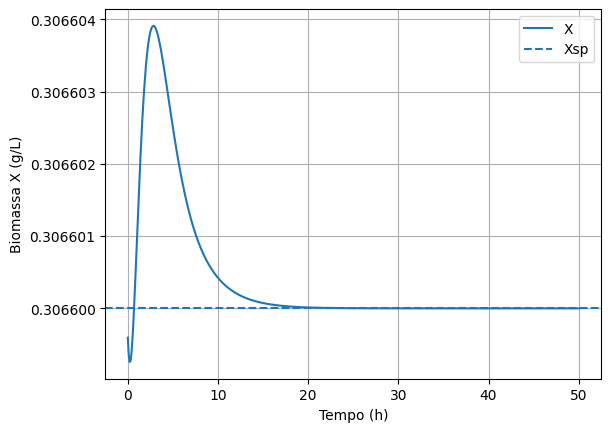

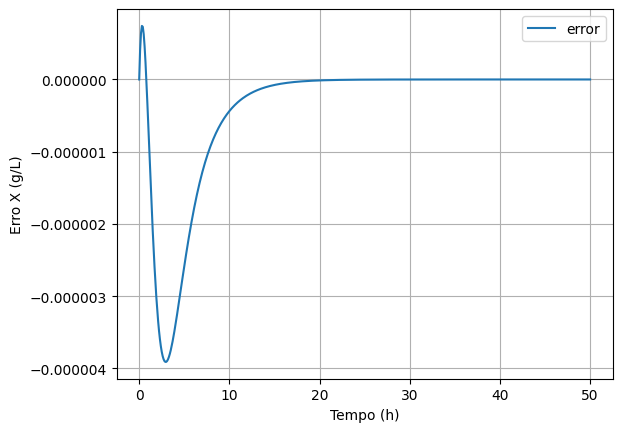

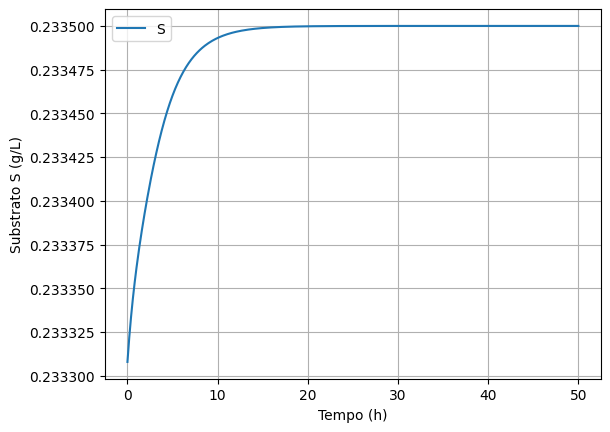

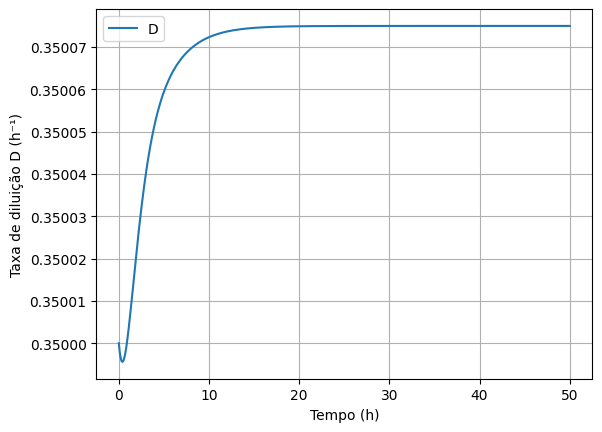

2.0207291676790917e-05 5.1111430780470366e-11 -3.628763955987324e-13


In [ ]:
ttop, Xtop, Stop, Dtop, IAE_top, ISE_top, erro = simular_PID(Kc=povo["fortes"][0][0], Ti=povo["fortes"][0][1], Xsp=Xsp, D0=D0, states=states, tempo_final=50, dt=0.1, show=True)
print(IAE_top, ISE_top, erro[-1])